# Rice Heading Date Prediction from Genetic Markers

This notebook demonstrates how to apply a pre-trained machine learning model to predict rice heading dates based on genetic marker data (SNPs). 

## Overview
1. Load a pre-trained model for rice heading date prediction
2. Import and prepare new rice genotype data 
3. Apply feature selection to focus on the most relevant genetic markers
4. Handle missing data through imputation
5. Generate heading date predictions 
6. Visualize the distribution of predicted dates
7. Export results as CSV and figures

## Requirements

You can run this notebook in two ways:

### Option 1: Local Installation
- Python 3.7+
- RAPIDS cuDF (for GPU acceleration)
- pandas, numpy, matplotlib
- Pre-trained model files (best_trained_model_hdg_80head2025.pkl)
- Feature selection file (combined_selected_features_top_1000.csv)
- Missing value imputer (most_freq_imputer_hdg_80head2025.pkl)

### Option 2: Docker Container (Recommended)
Use our pre-configured Docker image with all dependencies:
```bash
docker run --gpus all --ipc=host --ulimit memlock=-1 --ulimit stack=67108864 \
    --rm -p 10000:8888 -p 8501:8501 \
    -v ${PWD}:/workspace/mycode \
    abdelghafour1/ngc_tf_rapids_25_01_vscode_torch:2025-v3 \
    jupyter lab --ip=0.0.0.0 --allow-root \
    --NotebookApp.custom_display_url=http://$(hostname):10000
```
This container includes all required dependencies and GPU support.

- Pre-trained model files (best_trained_model_hdg_80head2025.pkl)
- Feature selection file (combined_selected_features_top_1000.csv)
- Missing value imputer (most_freq_imputer_hdg_80head2025.pkl)

In [1]:
# Load RAPIDS cuDF extension for GPU-accelerated pandas operations
%load_ext cudf.pandas

# Import essential data manipulation libraries
import pandas as pd
import numpy as np

## 1. Load Pre-Trained Model

The model was previously trained on historical rice genetics and heading date data. It can predict the number of days to heading based on genetic markers (SNPs).

Heading date is a key agricultural trait that impacts crop timing and yield.

In [2]:
# Import joblib for loading the saved model
import joblib

# Load the pre-trained model from disk
# This model was trained to predict heading dates based on genetic markers
best_model_for_deployment = joblib.load('best_trained_model_hdg_80head2025.pkl')

## 2. Import Genotype Data

Here we load genotype data from new rice samples in HapMap format. This file contains genetic markers (SNPs) for multiple rice samples.

> **Note:** You can adjust the file path to your own genotype file in HapMap format. The file should include an 'ID' column with sample identifiers.

In [3]:
%%time
# Load the genotype file that you want to make predictions on
# For this example, we use the Core.mind0.2.geno0.2.maf0.05.01.hdg_80head2025.hmp file
# Change this path to your own genotype file location
selected_filepath="/workspace/mycode/rice-genotype-phenotype-prediction/data/raw/Core.mind0.2.geno0.2.maf0.05.01.hdg_80head2025.hmp"
genotypes = pd.read_csv(selected_filepath, sep=",", header=0)

CPU times: user 4min 12s, sys: 8.91 s, total: 4min 21s
Wall time: 4min 29s


In [4]:
# Display the first 3 rows and the first 20 columns to inspect the data structure
genotypes.iloc[:3, :20] 

,ID,hdg_80head_2025,Chr01_9233_T_C_C,Chr01_13894_A_T_T,Chr01_25980_G_A_A,Chr01_28467_C_G_G,Chr01_31071_A_G_A,Chr01_31478_C_T_T,Chr01_34534_T_C_C,Chr01_41342_A_G_G,Chr01_41890_T_C_T,Chr01_44681_C_T_T,Chr01_46283_A_G_G,Chr01_48321_C_T_T,Chr01_49376_G_A_A,Chr01_49413_A_T_T,Chr01_60170_A_G_G,Chr01_65544_C_A_A,Chr01_85413_C_T_T,Chr01_88888_A_G_G
0,ERS467753,<NA>,0,0,0,0,0,2,0,0,0,0,0,0,2,0,0,0,0,0
1,ERS467754,<NA>,2,0,0,2,0,0,0,0,0,0,2,-9,0,0,2,0,2,0
2,ERS467755,<NA>,0,0,0,0,0,2,0,2,0,0,0,0,0,0,0,0,0,0


## 3. Apply Feature Selection

Not all genetic markers are equally relevant for predicting heading date. We use a pre-determined list of the top 1,000 most informative features (SNPs) selected during model development.

This feature selection:
1. Reduces dimensionality
2. Focuses on the most relevant genetic signals
3. Improves prediction performance
4. Reduces computational requirements

In [5]:
# Create a reference to the genotypes dataframe
df = genotypes

# Load the pre-selected features from file
features_path = "combined_selected_features_top_1000.csv"
selected_features_df = pd.read_csv(features_path)

# Extract the feature names as a list
selected_features = selected_features_df["feature"].tolist()

# Display how many features we're using
len(selected_features)

3368

In [6]:
# Filter the dataframe to only include the selected features
df_subset = df[selected_features]

# Display a sample of the filtered data
df_subset.iloc[:3, :20] 

,Chr02_6175004_C_T_C,Chr02_13754794_C_T_T,Chr04_413920_G_T_T,Chr07_16911636_G_A_A,Chr09_11246821_G_A_A,Chr03_9987952_C_A_A,Chr02_4193412_C_T_T,Chr12_18006180_T_C_C,Chr05_28597819_T_G_G,Chr07_1192546_C_T_T,Chr04_2041542_C_T_T,Chr04_5377485_C_T_T,Chr03_31667319_A_T_T,Chr02_18614751_C_T_T,Chr01_12733654_G_A_G,Chr06_30826962_C_T_T,Chr01_31585059_G_A_A,Chr04_31044018_G_C_C,Chr03_24211509_C_T_T,Chr02_5393562_G_C_G
0,2,2,0,0,2,0,0,0,0,0,0,-9,2,0,-9,2,0,2,0,-9
1,0,2,2,2,0,0,0,2,0,2,2,2,2,0,0,0,0,0,0,-9
2,-9,0,2,0,0,0,0,2,2,0,2,-9,2,0,0,2,2,0,0,1


In [7]:
# Check the shape of our filtered dataset (rows × columns)
df_subset.shape

(16779, 3368)

## 4. Handle Missing Data

Genotype data often contains missing values (typically coded as -9 in HapMap format). We need to:
1. Identify missing values
2. Replace them with NaN for proper handling
3. Apply imputation to fill in the missing values

Imputation is critical for ensuring the model can use all samples without errors due to missing data.

In [8]:
# Replace missing value codes (-9) with numpy NaN
df_to_predict = df_subset.replace(-9, np.nan)

/usr/local/lib/python3.12/dist-packages/cudf/core/column/numerical.py:730: RuntimeWarning: invalid value encountered in cast
  col_to_normalize_casted = np.array(col_to_normalize[0]).astype(


In [9]:
# Display the data with missing values now shown as NaN
df_to_predict.iloc[:3, :20] 

,Chr02_6175004_C_T_C,Chr02_13754794_C_T_T,Chr04_413920_G_T_T,Chr07_16911636_G_A_A,Chr09_11246821_G_A_A,Chr03_9987952_C_A_A,Chr02_4193412_C_T_T,Chr12_18006180_T_C_C,Chr05_28597819_T_G_G,Chr07_1192546_C_T_T,Chr04_2041542_C_T_T,Chr04_5377485_C_T_T,Chr03_31667319_A_T_T,Chr02_18614751_C_T_T,Chr01_12733654_G_A_G,Chr06_30826962_C_T_T,Chr01_31585059_G_A_A,Chr04_31044018_G_C_C,Chr03_24211509_C_T_T,Chr02_5393562_G_C_G
0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0,0.0,NaN,2.0,0.0,2.0,0.0,NaN
1,0.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,NaN,0.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,NaN,2.0,0.0,0.0,2.0,2.0,0.0,0.0,1.0


In [10]:
%%time
# Load and apply the imputer to fill in missing values

import joblib

# Load the pre-trained imputer model
imputer_path = "most_freq_imputer_hdg_80head2025.pkl"
imputer = joblib.load(imputer_path)

# Get list of all SNP columns
snp_cols = [col for col in df_to_predict.columns]

# Apply imputation to fill in missing values
imputed_snp_data = imputer.transform(df_to_predict)

# Convert imputed array back to DataFrame format
imputed_snp_df = pd.DataFrame(imputed_snp_data, columns=snp_cols, index=df_to_predict.index)

# Create a copy of the original DataFrame and replace SNP columns with imputed values
df_to_predict_imputed = df_to_predict.copy()
df_to_predict_imputed[snp_cols] = imputed_snp_df

CPU times: user 2min 58s, sys: 1.38 s, total: 3min
Wall time: 3min


In [11]:
# Check the imputed data to ensure no missing values remain
df_to_predict_imputed.iloc[:3, :20] 

,Chr02_6175004_C_T_C,Chr02_13754794_C_T_T,Chr04_413920_G_T_T,Chr07_16911636_G_A_A,Chr09_11246821_G_A_A,Chr03_9987952_C_A_A,Chr02_4193412_C_T_T,Chr12_18006180_T_C_C,Chr05_28597819_T_G_G,Chr07_1192546_C_T_T,Chr04_2041542_C_T_T,Chr04_5377485_C_T_T,Chr03_31667319_A_T_T,Chr02_18614751_C_T_T,Chr01_12733654_G_A_G,Chr06_30826962_C_T_T,Chr01_31585059_G_A_A,Chr04_31044018_G_C_C,Chr03_24211509_C_T_T,Chr02_5393562_G_C_G
0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0
1,0.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,1.0


## 5. Prepare Data for Prediction

To use our model, we need to convert the data to a NumPy array with the correct data type.

In [12]:
# Convert the DataFrame to a NumPy array for model input
X_new = df_to_predict_imputed.values

# Ensure data is in float64 format as required by most models
X_new = np.array(X_new, dtype=np.float64)

## 6. Generate Predictions

Now we can apply our pre-trained model to predict heading dates for the new rice samples.

In [13]:
# Apply the model to predict heading dates
y_pred_new = best_model_for_deployment.predict(X_new)

[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] lambda_l1 is set=7.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=7.0


In [14]:
# Create a new DataFrame with sample identifiers and predicted values
df_y_pred = pd.DataFrame({
    "ID": genotypes['ID'],  # Sample identifiers from original data
    "y_pred_new": y_pred_new      # Predicted heading dates from our model
})

# Display the results DataFrame
df_y_pred

,ID,y_pred_new
0,ERS467753,93.285809
1,ERS467754,87.887529
2,ERS467755,96.124777
3,ERS467756,94.761453
4,ERS467757,109.513464
...,...,...
16774,SAMN20901686,81.302035
16775,SAMN20901687,81.041919
16776,SAMN20901689,74.114168
16777,SAMN20901690,75.587738


## 7. Visualize Prediction Distribution

Visualizing the distribution of predicted heading dates helps us understand:
- The range of heading dates in our samples
- Central tendencies (mean, median)
- Potential subpopulations or clusters

This visualization also helps identify any unusual patterns or outliers in the predictions.

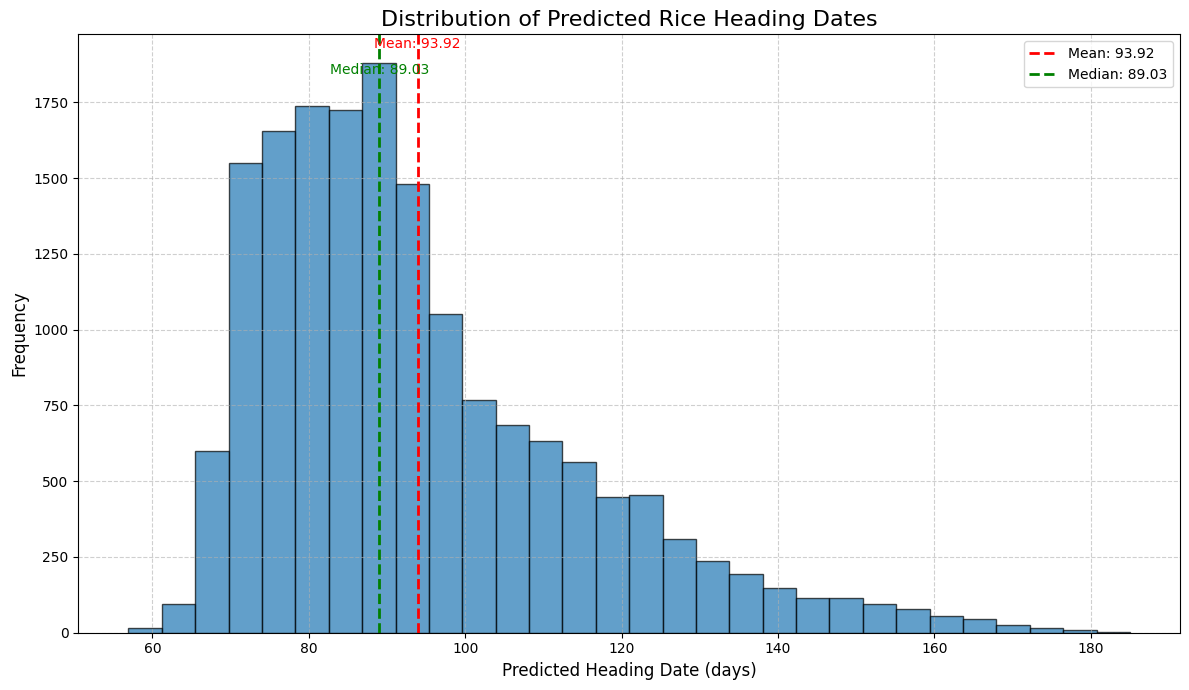

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    # Check if df_y_pred exists (if running in a continuous session)
    df_y_pred = df_y_pred.copy()
except NameError:
    # If not, create a sample DataFrame with simulated data for demonstration
    data = {
        'ID': [f'ERS{467753+i}' for i in range(5500)] + [f'SAMN{20901686+i}' for i in range(18)],
        'y_pred_new': np.random.normal(loc=90, scale=15, size=5518)
    }
    # Add some variety to the simulated data to show multiple modes
    data['y_pred_new'][:100] = np.random.uniform(40, 60, size=100)  # Early heading varieties
    data['y_pred_new'][5400:] = np.random.uniform(100, 130, size=118)  # Late heading varieties
    df_y_pred = pd.DataFrame(data)


# --- Calculate key statistics for annotations ---
mean_pred = df_y_pred['y_pred_new'].mean()
median_pred = df_y_pred['y_pred_new'].median()

# --- Create Matplotlib Figure and Axes ---
# Set figure size for good readability
fig, ax = plt.subplots(figsize=(12, 7))

# --- Create Matplotlib Histogram ---
n_bins = 30
counts, bins, patches = ax.hist(df_y_pred['y_pred_new'], bins=n_bins, edgecolor='k', alpha=0.7)

# --- Add Mean and Median Lines ---
ax.axvline(mean_pred, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_pred:.2f}')
ax.axvline(median_pred, color='green', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')

# --- Add Text Annotations for Mean/Median ---
# Position text annotations above the histogram bars
max_freq = counts.max()
text_y = max_freq * 1.02  # Position text slightly above the max bar

# Add text labels for mean and median values
ax.text(mean_pred, text_y, f'Mean: {mean_pred:.2f}', color='red', ha='center', va='bottom', fontsize=10)
ax.text(median_pred, text_y * 0.98, f'Median: {median_pred:.2f}', color='green', ha='center', va='top', fontsize=10)

# --- Enhance Layout ---
ax.set_title('Distribution of Predicted Rice Heading Dates', fontsize=16)
ax.set_xlabel('Predicted Heading Date (days)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Add a legend for reference
ax.legend()

# Ensure layout is tight to prevent labels overlapping
fig.tight_layout()

# --- Display the Interactive Visualization ---
fig.show()

## 8. Export Results

Save the visualization and prediction results for future reference and sharing.

- The PDF export provides a high-quality figure for publications or presentations
- The CSV export allows for further analysis or integration with other datasets

In [16]:
# Create output directory if it doesn't exist
import os
os.makedirs('output', exist_ok=True)

# --- Export the figure as PDF ---
# High resolution (300 dpi) for publication quality
pdf_filepath = "output/rice_heading_date_distribution_predicted.pdf"
fig.savefig(pdf_filepath, dpi=300, bbox_inches='tight')
print(f"Figure successfully exported as {pdf_filepath}")

Figure successfully exported as output/rice_heading_date_distribution_predicted.pdf


In [17]:
# Save the predictions to a CSV file, including both sample IDs and predicted heading dates
# The resulting CSV can be used for further analysis or shared with collaborators
df_y_pred.to_csv("output/heading_date_predictions_on_new_samples_with_ID_using_ultimate_model.csv", index=False)

print("Predictions saved as 'heading_date_predictions_on_new_samples_with_ID_using_ultimate_model.csv'")

Predictions saved as 'heading_date_predictions_on_new_samples_with_ID_using_ultimate_model.csv'
